In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 80 from C header, got 96 from PyObject


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


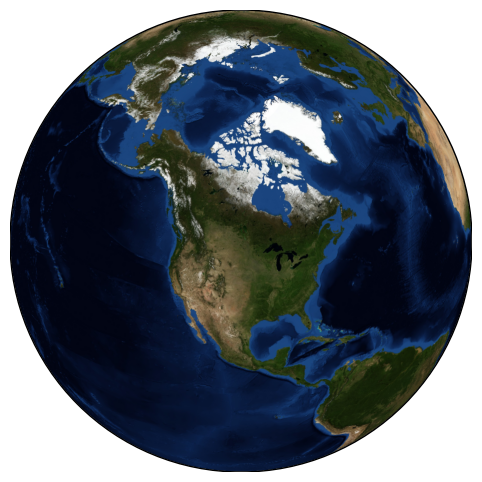

In [3]:
plt.figure(figsize=(8, 6))
m = Basemap(projection="ortho", resolution=None, lat_0=50, 
           lon_0=-100)
m.bluemarble(scale=0.5);

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


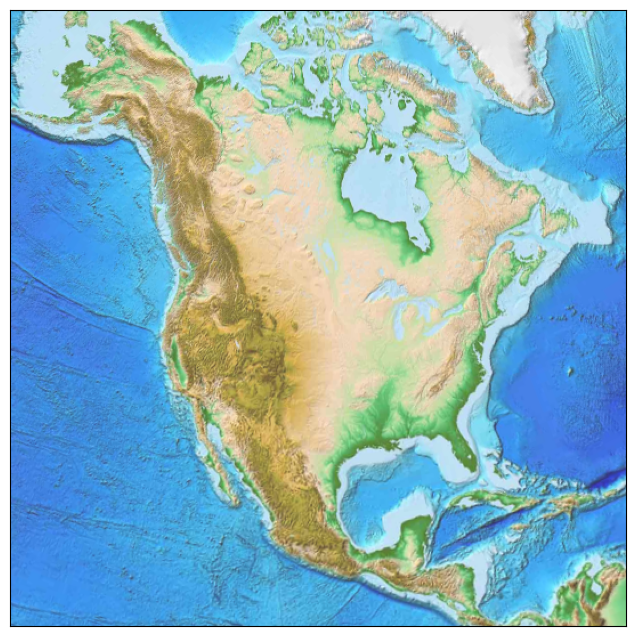

In [5]:
fig = plt.figure(figsize=(8, 8))
m = Basemap(projection="lcc", resolution=None,
            width=8E6, height=8E6,
            lat_0=45, lon_0=-100)
m.etopo(scale=0.5, alpha=0.8);

In [6]:
cities = pd.read_csv("../data/california_cities.csv")

cities.columns

Index(['Unnamed: 0', 'city', 'latd', 'longd', 'elevation_m', 'elevation_ft',
       'population_total', 'area_total_sq_mi', 'area_land_sq_mi',
       'area_water_sq_mi', 'area_total_km2', 'area_land_km2', 'area_water_km2',
       'area_water_percent'],
      dtype='object')

In [7]:
# The extraction: data we will use directly

lats = cities["latd"].values
lons = cities["longd"].values
population = cities["population_total"].values
area = cities["area_total_km2"].values


In [8]:
lats


array([34.57611111, 34.15333333, 37.75611111, 37.88694444, 34.08194444,
       33.575     , 41.48722222, 38.41944444, 38.16805556, 33.83611111,
       40.45222222, 38.06833333, 38.005     , 34.51666667, 34.13277778,
       40.86638889, 35.12083333, 33.86722222, 35.20916667, 35.48416667,
       37.45861111, 37.34777778, 38.89861111, 33.34083333, 36.00416667,
       34.13055556, 35.36666667, 34.08277778, 33.93166667, 34.9       ,
       33.92416667, 33.98333333, 33.88805556, 33.96805556, 37.51805556,
       37.87277778, 38.06333333, 37.87166667, 34.07305556, 34.24138889,
       39.41388889, 37.3635    , 40.88277778, 33.61027778, 34.14944444,
       32.97861111, 33.92333333, 37.93194444, 37.68083333, 34.61416667,
       33.85611111, 34.18027778, 37.58333333, 34.13833333, 32.67888889,
       35.12583333, 33.98805556, 33.12555556, 38.58138889, 34.23333333,
       37.28388889, 33.68416667, 36.97638889, 33.12194444, 36.55527778,
       34.39916667, 33.83972222, 33.80777778, 37.60138889, 33.86

#### 1. Draw the map background

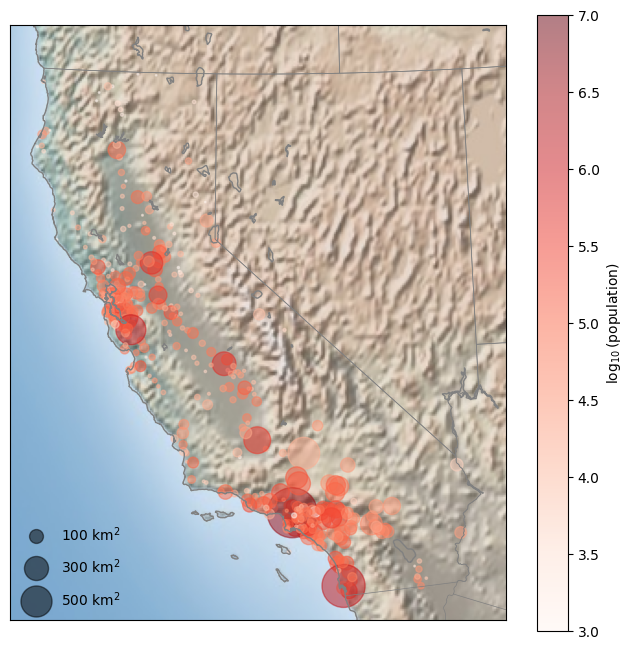

In [17]:
fig = plt.figure(figsize=(8, 8))
m = Basemap(projection='lcc', resolution='h', 
            lat_0=37.5, lon_0=-119,
            width=1E6, height=1.2E6)
m.shadedrelief()
m.drawcoastlines(color='gray')
m.drawcountries(color='gray')
m.drawstates(color='gray')

# 2. scatter city data, with color reflecting population and size reflecting area
m.scatter(lons, lats, latlon=True,
          c=np.log10(population), s=area,
          cmap='Reds', alpha=0.5)

# 3. create colorbar and legend
plt.colorbar(label=r'$\log_{10}({\rm population})$')
plt.clim(3, 7)

# make legend with dummy points
for a in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.5, s=a,
                label=str(a) + ' km$^2$')
plt.legend(scatterpoints=1, frameon=False,
           labelspacing=1, loc='lower left');

The area where the people are densely populated are around the coast down south and a little up north but the middle area is well avoided.

In [12]:
np.log10(population)

array([4.50194886, 4.30813738, 4.87775709, 4.27804444, 4.91954353,
       4.67963682, 3.45132581, 2.26717173, 4.28900891, 5.52633928,
       3.99703671, 3.5838786 , 5.02978947, 4.83969797, 4.75100181,
       4.23631048, 4.24836567, 4.21806262, 4.28564731, 4.45193987,
       3.83972938, 4.44975601, 4.12483015, 3.5714759 , 4.12185518,
       4.6661528 , 5.54093356, 4.87731374, 4.47133573, 4.35485724,
       4.56675558, 4.54994689, 4.88431947, 4.62399316, 4.41220847,
       3.31555053, 4.43131551, 5.05146124, 4.53516749, 3.7006172 ,
       3.23223352, 3.58871978, 3.09795107, 4.31841814, 3.02036128,
       4.39712277, 4.59419359, 4.71164697, 3.63164666, 3.68376726,
       4.9059577 , 5.01426846, 4.45948296, 4.36282163, 4.58627216,
       4.1498347 , 3.8964711 , 3.88677264, 3.71222867, 4.81425426,
       4.5949337 , 4.02370504, 3.9964241 , 5.02254384, 3.57077637,
       4.11527759, 4.96243564, 4.70926996, 4.65721844, 4.69055932,
       4.93544176, 4.89199994, 4.87883764, 4.27230584, 5.38724

In [33]:
cities.drop(columns="Unnamed: 0", inplace=True)

In [34]:
cities

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


## Temperature DATA

In [35]:
from netCDF4 import Dataset
from netCDF4 import date2index
from datetime import datetime


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [36]:
# Getting 
data = Dataset("../data/gistemp250_GHCNv4.nc")
timeindex = date2index(datetime(2014, 1, 15), data.variables["time"])

In [37]:
data

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    title: GISTEMP Surface Temperature Analysis
    institution: NASA Goddard Institute for Space Studies
    source: http://data.giss.nasa.gov/gistemp/
    Conventions: CF-1.6
    history: Created 2025-09-10 02:53:53 by SBBX_to_nc 2.0 - ILAND=250,  IOCEAN=none,     Base: 1951-1980
    dimensions(sizes): lat(90), lon(180), time(1748), nv(2)
    variables(dimensions): float32 lat(lat), float32 lon(lon), int32 time(time), int32 time_bnds(time, nv), int16 tempanomaly(time, lat, lon)
    groups: 

In [38]:
timeindex

1608

In [39]:
lat = data.variables["lat"][:]
lon = data.variables["lon"][:]
lon, lat = np.meshgrid(lon, lat)
temp_anom = data.variables["tempanomaly"][timeindex]

In [45]:
data.variables["time"][:]

masked_array(data=[29233, 29264, 29293, ..., 82345, 82375, 82406],
             mask=False,
       fill_value=np.int64(999999),
            dtype=int32)

/tmp/ipykernel_364532/3796937439.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m.pcolormesh(lon, lat, temp_anom, latlon=True, cmap="RdBu_r")


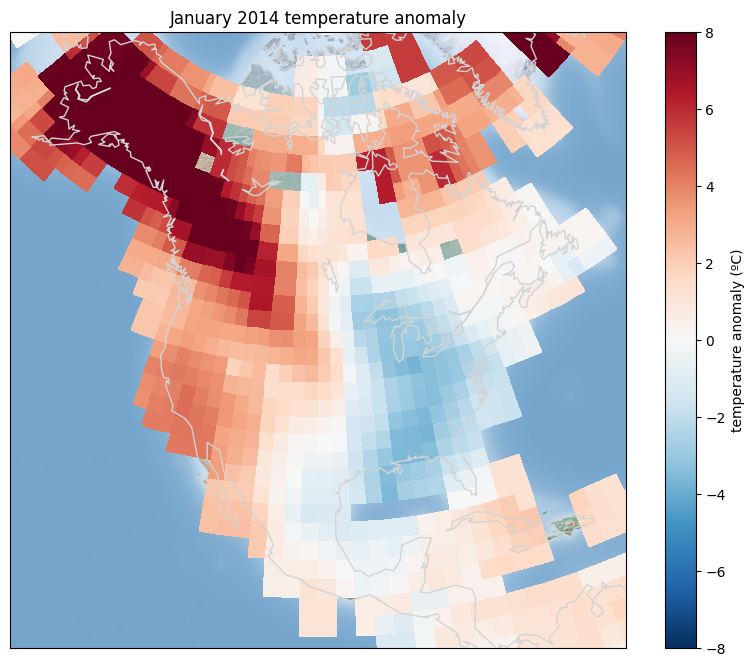

In [47]:
fig = plt.figure(figsize=(10, 8))

m = Basemap(projection="lcc", resolution="c",
            width=8E6, height=8E6,
            lat_0=45, lon_0=-100)

m.shadedrelief(scale=0.5)
m.pcolormesh(lon, lat, temp_anom, latlon=True, cmap="RdBu_r")
plt.clim(-8, 8)
m.drawcoastlines(color="lightgray")

plt.title("January 2014 temperature anomaly")
plt.colorbar(label="temperature anomaly (ºC)");